# Exploratory Data Analysis (EDA) - Emotion Dataset
## 20 Emotions Classification Dataset

This notebook performs comprehensive EDA on the emotion dataset containing text samples labeled with 20 different emotions.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## 1. Load the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('../data/raw/emotion_dataset_v5_clean.csv')

print(f"Dataset shape: {df.shape}")
print(f"Number of samples: {len(df):,}")
print(f"Number of features: {df.shape[1]}")

Dataset shape: (79595, 3)
Number of samples: 79,595
Number of features: 3


## 2. Basic Data Overview

In [3]:
# Display first few rows
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,sentence,emotion,cleaned_text
0,I'm so furious with you right now.,anger,i'm so furious with you right now.
1,My day is ruined because of this crap.,anger,my day is ruined because of this crap.
2,I feel like I'm about to explode.,anger,i feel like i'm about to explode.
3,This is the worst day of my life.,anger,this is the worst day of my life.
4,I hate everything about this situation.,anger,i hate everything about this situation.
5,"I'm beyond angry, I'm livid right now.",anger,"i'm beyond angry, i'm livid right now."
6,My blood is boiling just thinking about it.,anger,my blood is boiling just thinking about it.
7,I'm fed up with all these lies and excuses.,anger,i'm fed up with all these lies and excuses.
8,This is seriously pissing me off right now.,anger,this is seriously pissing me off right now.
9,I've had enough of your nonsense already.,anger,i've had enough of your nonsense already.


In [4]:
# Dataset info
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79595 entries, 0 to 79594
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   sentence      79595 non-null  object
 1   emotion       79595 non-null  object
 2   cleaned_text  79595 non-null  object
dtypes: object(3)
memory usage: 1.8+ MB


In [5]:
# Column names and data types
print("\nColumn Names and Data Types:")
print(df.dtypes)


Column Names and Data Types:
sentence        object
emotion         object
cleaned_text    object
dtype: object


In [6]:
# Statistical summary
print("\nStatistical Summary:")
df.describe(include='all')


Statistical Summary:


,sentence,emotion,cleaned_text
count,79595,79595,79595
unique,79595,20,79517
top,I'm so furious with you right now.,happiness,my neighbor's noise is driving me crazy tonight.
freq,1,7797,2


## 3. Missing Values Analysis

In [7]:
# Check for missing values
print("Missing Values:")
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Count': missing_values.values,
    'Percentage': missing_percentage.values
})
print(missing_df)

# Visualize missing values
if missing_values.sum() > 0:
    plt.figure(figsize=(10, 4))
    missing_values[missing_values > 0].plot(kind='bar')
    plt.title('Missing Values by Column')
    plt.ylabel('Count')
    plt.xlabel('Columns')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ No missing values found in the dataset!")

Missing Values:
         Column  Missing Count  Percentage
0      sentence              0         0.0
1       emotion              0         0.0
2  cleaned_text              0         0.0

✓ No missing values found in the dataset!


## 4. Emotion Distribution Analysis

In [8]:
# Count of each emotion
emotion_counts = df['emotion'].value_counts()
print("Emotion Distribution:")
print(emotion_counts)
print(f"\nNumber of unique emotions: {df['emotion'].nunique()}")

Emotion Distribution:
emotion
happiness         7797
disgust           4315
jealousy          4081
surprise          4062
gratitude         4004
relief            3964
guilt             3961
anger             3860
disappointment    3832
embarrassment     3788
anxiety           3776
pride             3772
hope              3770
loneliness        3751
excitement        3643
fear              3574
sadness           3559
confusion         3429
love              3365
frustration       3292
Name: count, dtype: int64

Number of unique emotions: 20


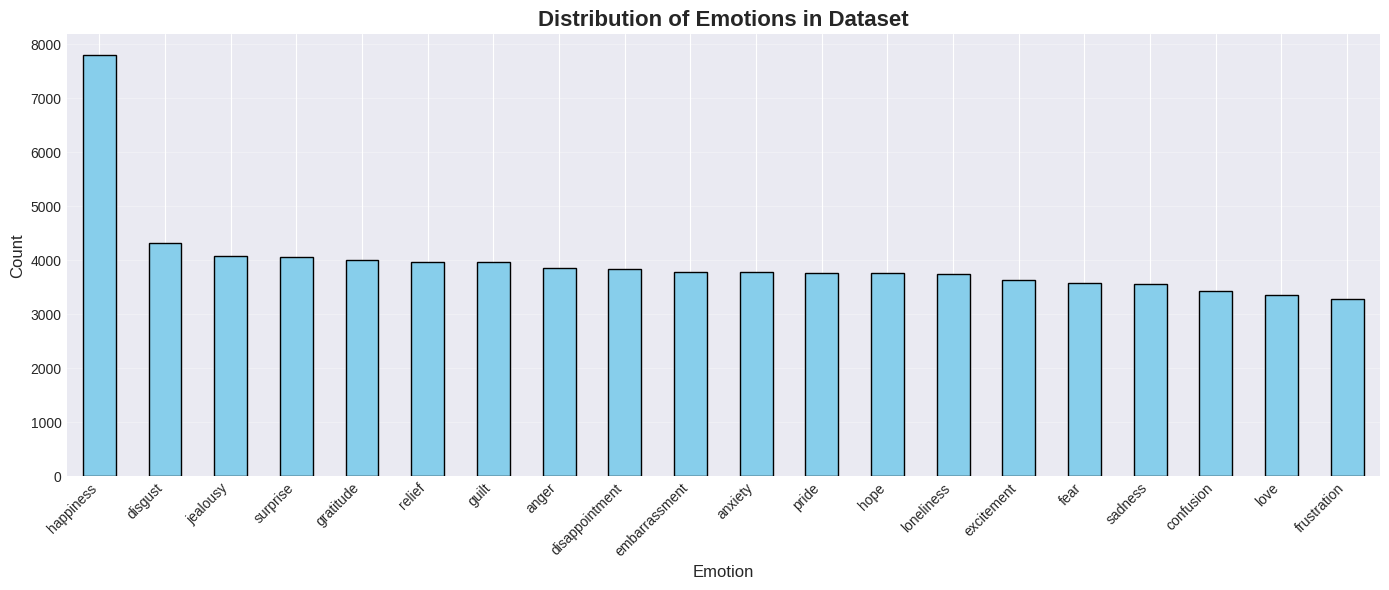

In [9]:
# Visualize emotion distribution - Bar plot
plt.figure(figsize=(14, 6))
emotion_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Emotions in Dataset', fontsize=16, fontweight='bold')
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

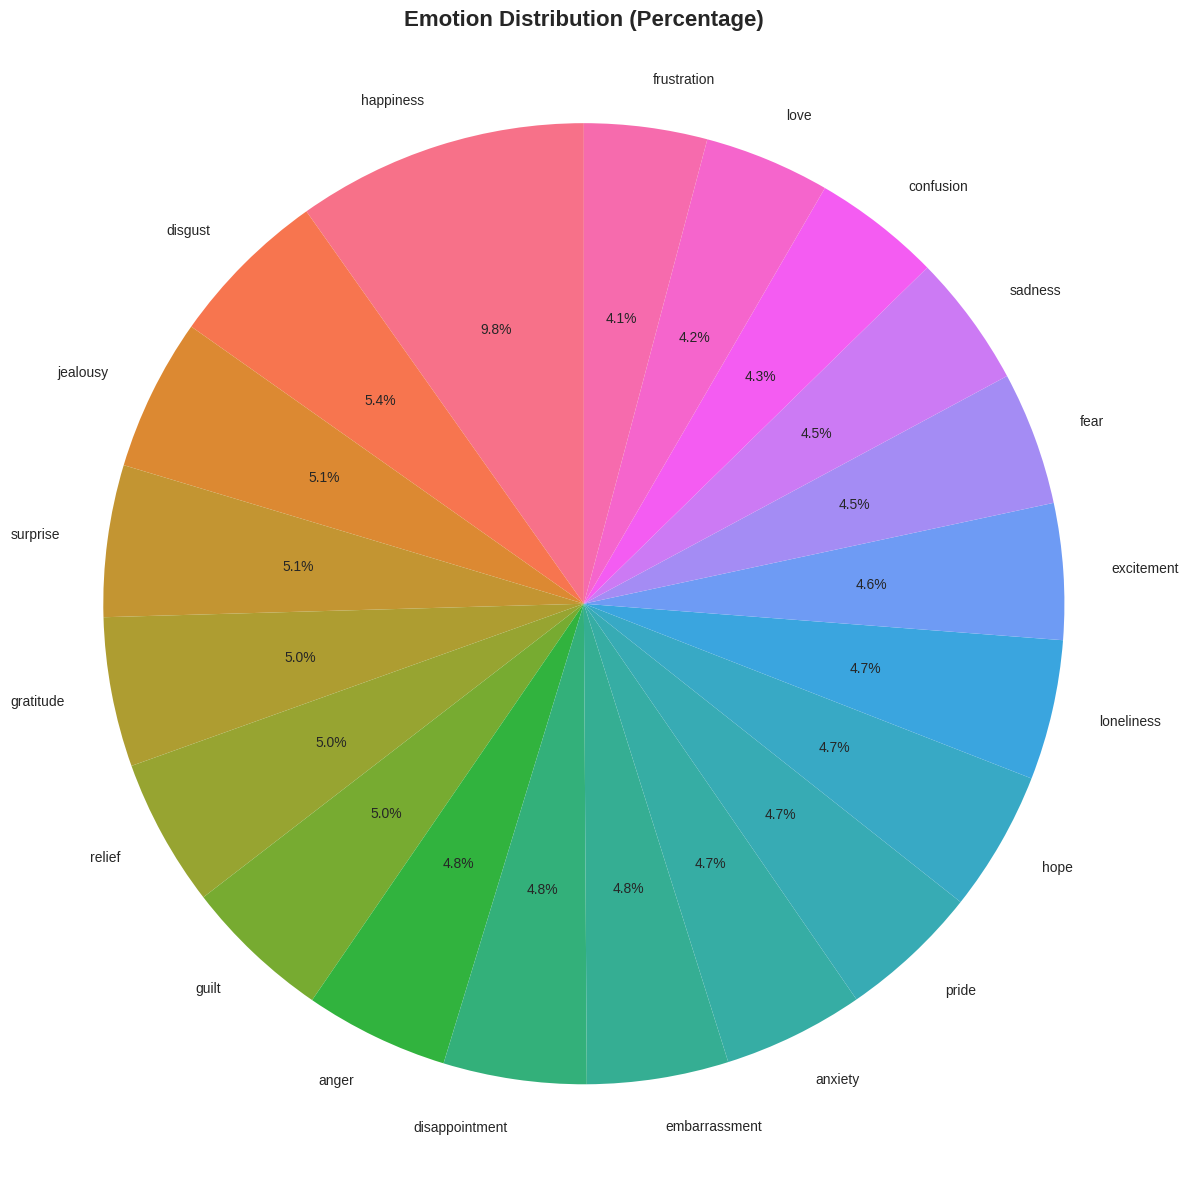

In [10]:
# Pie chart for emotion distribution
plt.figure(figsize=(12, 12))
colors = sns.color_palette('husl', len(emotion_counts))
plt.pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=colors)
plt.title('Emotion Distribution (Percentage)', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [11]:
# Check for class imbalance
print("\nClass Balance Analysis:")
print(f"Most common emotion: {emotion_counts.index[0]} ({emotion_counts.values[0]:,} samples)")
print(f"Least common emotion: {emotion_counts.index[-1]} ({emotion_counts.values[-1]:,} samples)")
print(f"Imbalance ratio: {emotion_counts.values[0] / emotion_counts.values[-1]:.2f}x")

# Calculate percentage for each emotion
emotion_percentage = (emotion_counts / len(df) * 100).round(2)
balance_df = pd.DataFrame({
    'Emotion': emotion_counts.index,
    'Count': emotion_counts.values,
    'Percentage': emotion_percentage.values
})
print("\n", balance_df)


Class Balance Analysis:
Most common emotion: happiness (7,797 samples)
Least common emotion: frustration (3,292 samples)
Imbalance ratio: 2.37x

            Emotion  Count  Percentage
0        happiness   7797        9.80
1          disgust   4315        5.42
2         jealousy   4081        5.13
3         surprise   4062        5.10
4        gratitude   4004        5.03
5           relief   3964        4.98
6            guilt   3961        4.98
7            anger   3860        4.85
8   disappointment   3832        4.81
9    embarrassment   3788        4.76
10         anxiety   3776        4.74
11           pride   3772        4.74
12            hope   3770        4.74
13      loneliness   3751        4.71
14      excitement   3643        4.58
15            fear   3574        4.49
16         sadness   3559        4.47
17       confusion   3429        4.31
18            love   3365        4.23
19     frustration   3292        4.14


## 5. Text Length Analysis

In [12]:
# Assuming the text column is named 'text', 'sentence', or similar
# Let's first check column names
print("Column names:")
print(df.columns.tolist())

Column names:
['sentence', 'emotion', 'cleaned_text']


In [13]:
# Determine the text column (usually 'text', 'sentence', 'content', etc.)
text_columns = [col for col in df.columns if col.lower() in ['text', 'sentence', 'content', 'message', 'tweet']]
if text_columns:
    text_col = text_columns[0]
else:
    # If not found, use the column that's not 'emotion'
    text_col = [col for col in df.columns if col != 'emotion'][0]

print(f"Text column identified: '{text_col}'")

Text column identified: 'sentence'


In [14]:
# Calculate text statistics
df['text_length'] = df[text_col].astype(str).apply(len)
df['word_count'] = df[text_col].astype(str).apply(lambda x: len(x.split()))
df['avg_word_length'] = df[text_col].astype(str).apply(lambda x: np.mean([len(word) for word in x.split()] if x.split() else [0]))

print("Text Statistics:")
print(f"Average text length: {df['text_length'].mean():.2f} characters")
print(f"Average word count: {df['word_count'].mean():.2f} words")
print(f"Average word length: {df['avg_word_length'].mean():.2f} characters")
print(f"\nMin text length: {df['text_length'].min()} characters")
print(f"Max text length: {df['text_length'].max()} characters")
print(f"Min word count: {df['word_count'].min()} words")
print(f"Max word count: {df['word_count'].max()} words")

Text Statistics:
Average text length: 48.31 characters
Average word count: 8.67 words
Average word length: 4.72 characters

Min text length: 21 characters
Max text length: 122 characters
Min word count: 5 words
Max word count: 10 words


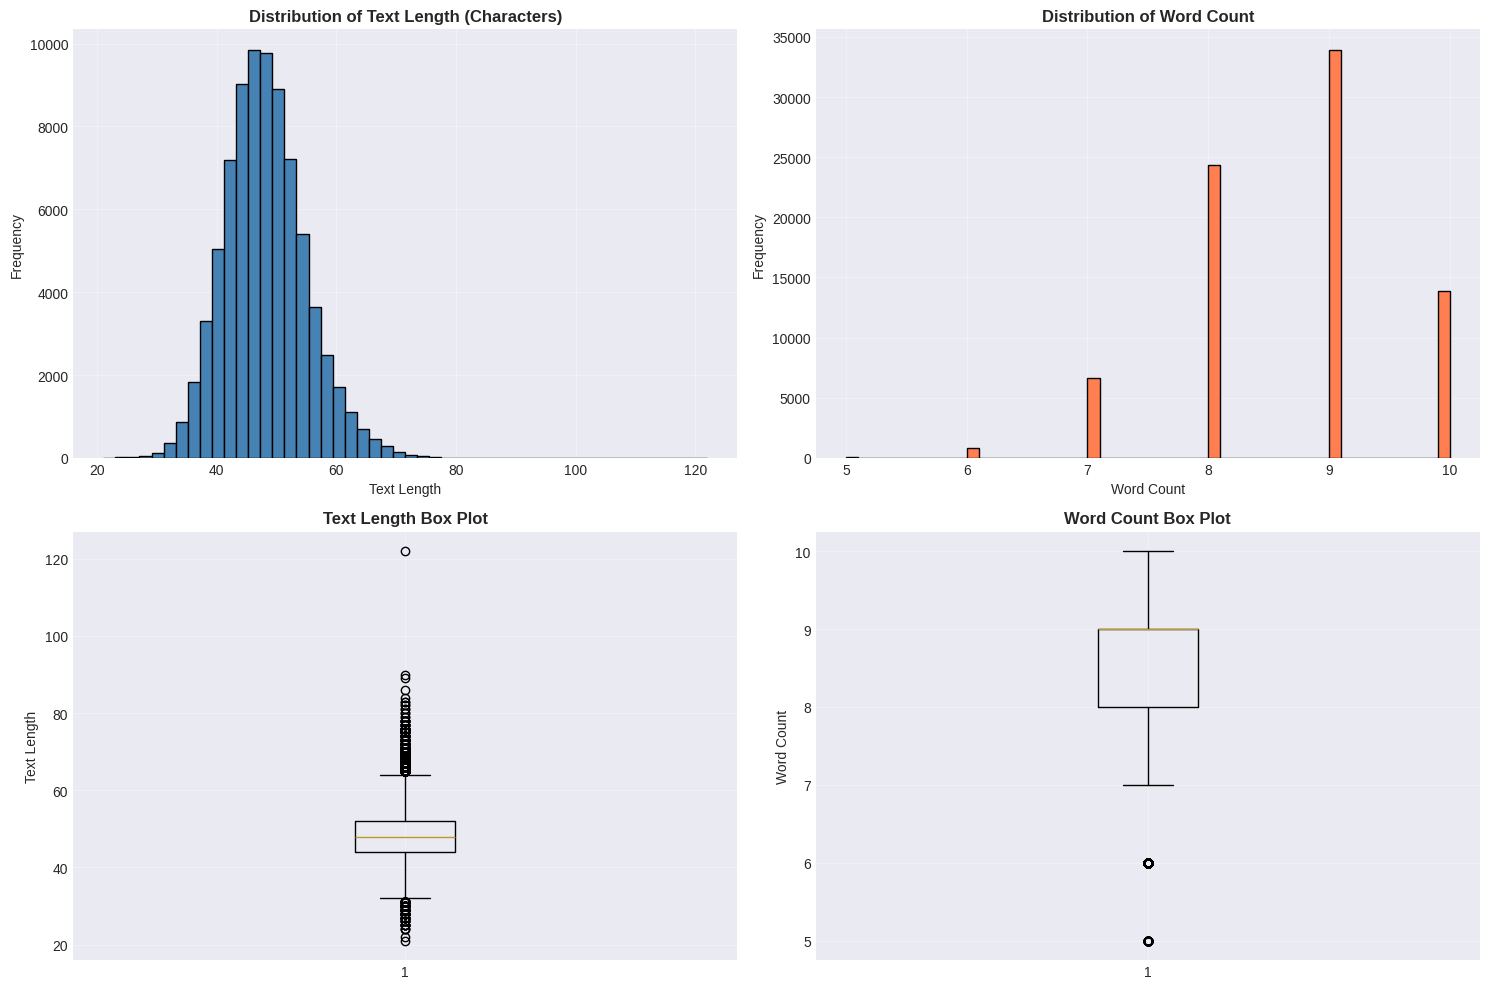

In [15]:
# Distribution of text lengths
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Text length distribution
axes[0, 0].hist(df['text_length'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Text Length (Characters)', fontweight='bold')
axes[0, 0].set_xlabel('Text Length')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(alpha=0.3)

# Word count distribution
axes[0, 1].hist(df['word_count'], bins=50, color='coral', edgecolor='black')
axes[0, 1].set_title('Distribution of Word Count', fontweight='bold')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(alpha=0.3)

# Box plot for text length
axes[1, 0].boxplot(df['text_length'], vert=True)
axes[1, 0].set_title('Text Length Box Plot', fontweight='bold')
axes[1, 0].set_ylabel('Text Length')
axes[1, 0].grid(alpha=0.3)

# Box plot for word count
axes[1, 1].boxplot(df['word_count'], vert=True)
axes[1, 1].set_title('Word Count Box Plot', fontweight='bold')
axes[1, 1].set_ylabel('Word Count')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Text length by emotion
emotion_text_stats = df.groupby('emotion').agg({
    'text_length': ['mean', 'median', 'std'],
    'word_count': ['mean', 'median', 'std']
}).round(2)

print("Text Statistics by Emotion:")
print(emotion_text_stats)

Text Statistics by Emotion:
               text_length              word_count             
                      mean median   std       mean median   std
emotion                                                        
anger                47.66   48.0  5.90       8.61    9.0  0.86
anxiety              48.98   49.0  5.64       8.74    9.0  0.88
confusion            45.31   45.0  5.43       8.39    8.0  0.97
disappointment       45.56   45.0  5.84       8.44    8.0  0.97
disgust              47.01   47.0  5.48       8.70    9.0  0.88
embarrassment        47.27   47.0  6.20       8.52    9.0  0.99
excitement           58.33   58.0  6.80       9.30    9.0  0.46
fear                 49.14   49.0  5.64       8.85    9.0  0.88
frustration          47.43   47.0  5.75       8.57    9.0  0.88
gratitude            48.44   48.0  5.62       8.79    9.0  0.88
guilt                47.85   48.0  5.74       8.68    9.0  0.90
happiness            54.39   54.0  6.55       8.58    9.0  0.67
hope        

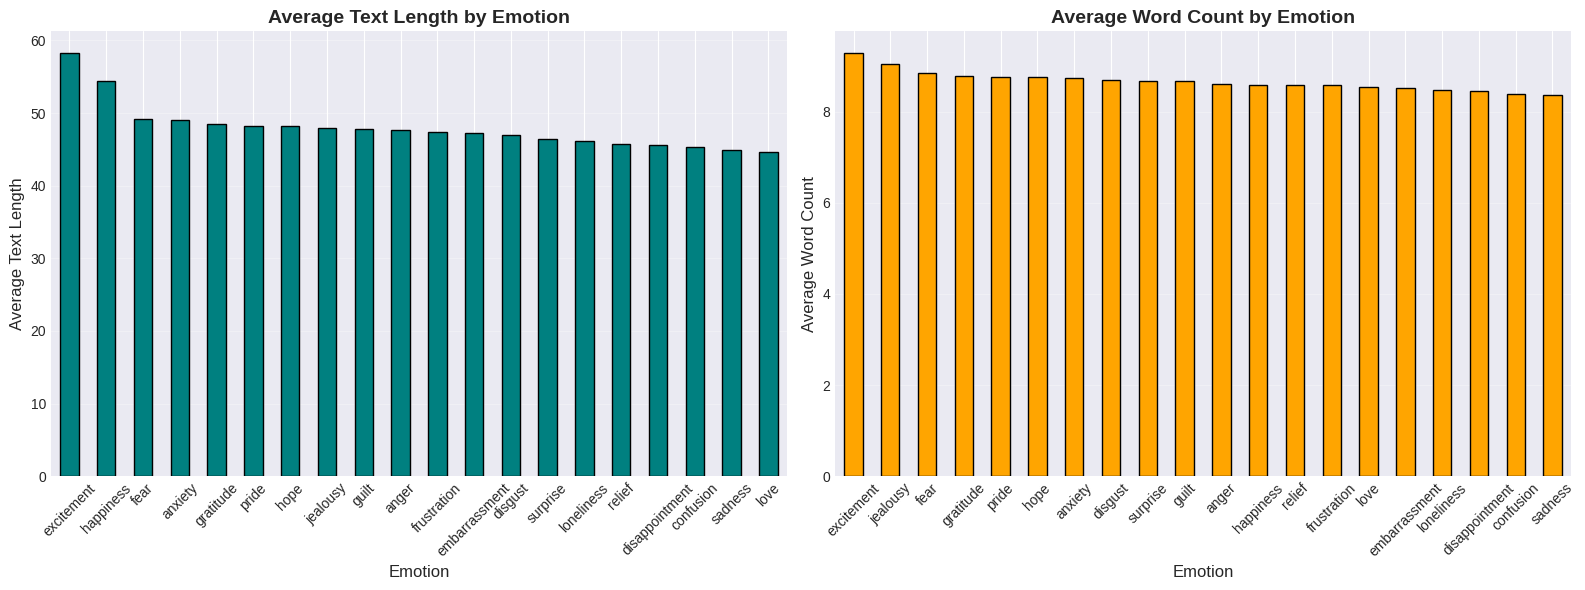

In [17]:
# Visualize average text length and word count by emotion
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average text length by emotion
avg_length_by_emotion = df.groupby('emotion')['text_length'].mean().sort_values(ascending=False)
avg_length_by_emotion.plot(kind='bar', ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Average Text Length by Emotion', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Emotion', fontsize=12)
axes[0].set_ylabel('Average Text Length', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Average word count by emotion
avg_words_by_emotion = df.groupby('emotion')['word_count'].mean().sort_values(ascending=False)
avg_words_by_emotion.plot(kind='bar', ax=axes[1], color='orange', edgecolor='black')
axes[1].set_title('Average Word Count by Emotion', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Emotion', fontsize=12)
axes[1].set_ylabel('Average Word Count', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Sample Texts by Emotion

In [18]:
# Display sample texts for each emotion
print("Sample Texts by Emotion:\n")
print("="*80)
for emotion in df['emotion'].unique()[:10]:  # Show first 10 emotions
    print(f"\n{emotion.upper()}:")
    print("-"*80)
    samples = df[df['emotion'] == emotion][text_col].head(3)
    for i, text in enumerate(samples, 1):
        print(f"{i}. {text}")
    print()

Sample Texts by Emotion:


ANGER:
--------------------------------------------------------------------------------
1. I'm so furious with you right now.
2. My day is ruined because of this crap.
3. I feel like I'm about to explode.


ANXIETY:
--------------------------------------------------------------------------------
1. I'm feeling a bit overwhelmed with work today.
2. My mind keeps racing before bedtime lately.
3. I'm getting anxious about the upcoming exam dates.


CONFUSION:
--------------------------------------------------------------------------------
1. I'm a bit unsure about this whole thing now
2. I don't get what's going on here exactly
3. My mind is kinda blank right now honestly


DISAPPOINTMENT:
--------------------------------------------------------------------------------
1. I'm so done with this day already.
2. Today was a complete waste of time.
3. My plans just got totally ruined.


DISGUST:
-----------------------------------------------------------------------

## 7. Most Common Words Analysis

In [19]:
# Get all words from texts
all_words = ' '.join(df[text_col].astype(str)).lower().split()
word_freq = Counter(all_words)
most_common_words = word_freq.most_common(30)

print("Top 30 Most Common Words:")
for word, count in most_common_words:
    print(f"{word}: {count:,}")

Top 30 Most Common Words:
my: 27,436
i: 18,827
i'm: 18,786
this: 14,357
is: 14,079
the: 12,280
a: 11,034
to: 9,663
me: 8,542
really: 7,796
so: 7,577
just: 7,302
about: 7,163
for: 7,110
feel: 7,021
of: 7,012
with: 6,860
today: 6,231
that: 6,225
feeling: 6,114
and: 5,165
was: 5,029
right: 4,825
today.: 4,518
in: 4,264
now.: 4,083
on: 3,885
pretty: 3,842
day: 3,755
out: 3,719


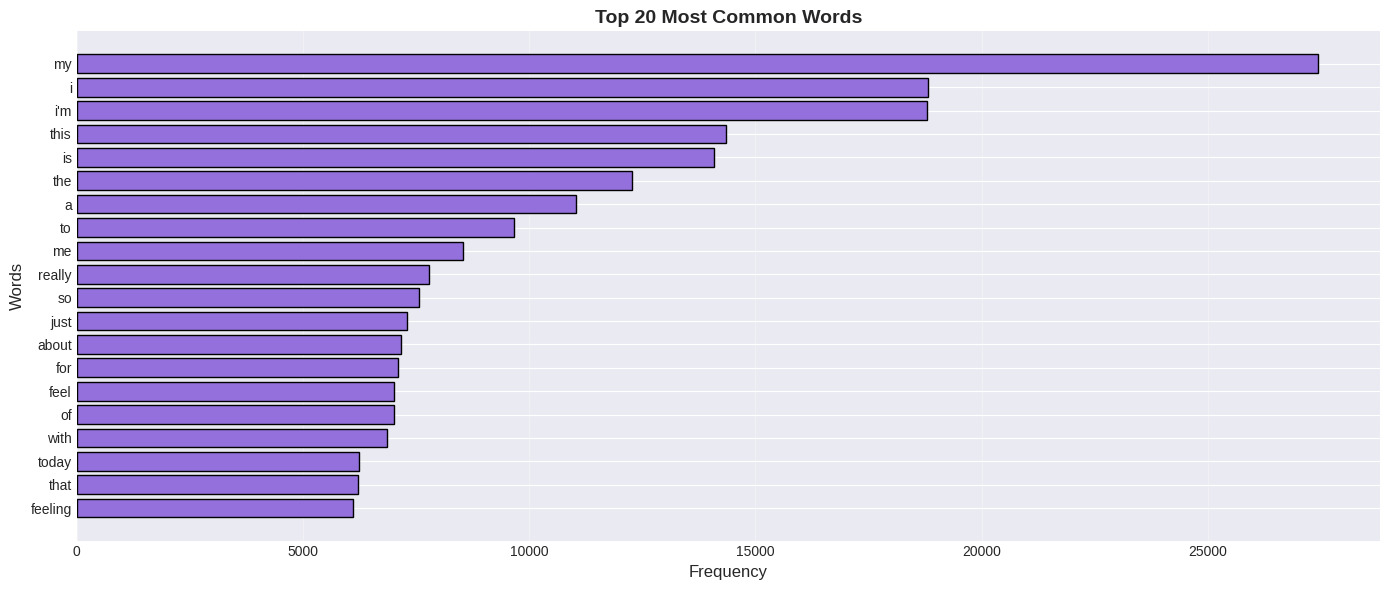

In [20]:
# Visualize most common words
words, counts = zip(*most_common_words[:20])
plt.figure(figsize=(14, 6))
plt.barh(range(len(words)), counts, color='mediumpurple', edgecolor='black')
plt.yticks(range(len(words)), words)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Words', fontsize=12)
plt.title('Top 20 Most Common Words', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Unique Words by Emotion

In [21]:
# Analyze unique vocabulary size per emotion
unique_words_by_emotion = {}
for emotion in df['emotion'].unique():
    emotion_texts = ' '.join(df[df['emotion'] == emotion][text_col].astype(str)).lower()
    unique_words = set(emotion_texts.split())
    unique_words_by_emotion[emotion] = len(unique_words)

unique_words_df = pd.DataFrame(list(unique_words_by_emotion.items()), 
                               columns=['Emotion', 'Unique Words']).sort_values('Unique Words', ascending=False)

print("Unique Vocabulary Size by Emotion:")
print(unique_words_df)

Unique Vocabulary Size by Emotion:
           Emotion  Unique Words
6       excitement          2529
11       happiness          2150
19        surprise          1991
4          disgust          1938
9        gratitude          1771
16           pride          1741
0            anger          1722
5    embarrassment          1663
10           guilt          1654
13        jealousy          1639
8      frustration          1611
17          relief          1610
3   disappointment          1608
7             fear          1575
18         sadness          1540
1          anxiety          1382
12            hope          1341
2        confusion          1322
14      loneliness          1317
15            love          1211


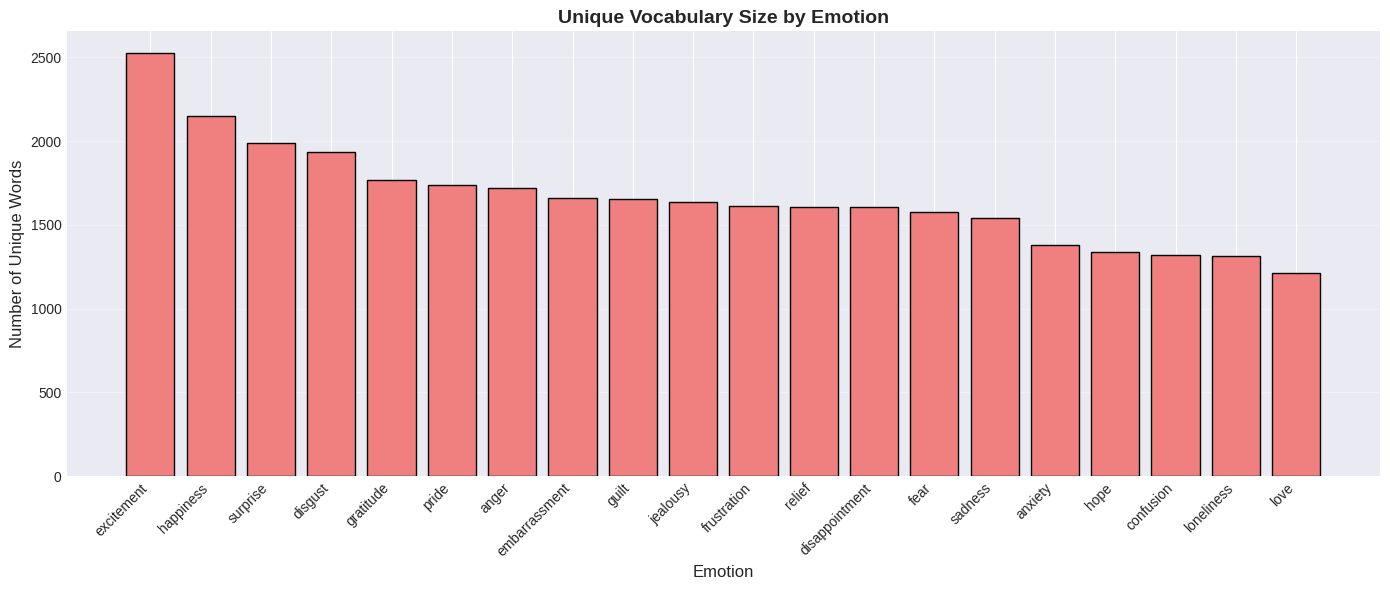

In [22]:
# Visualize unique words by emotion
plt.figure(figsize=(14, 6))
plt.bar(unique_words_df['Emotion'], unique_words_df['Unique Words'], 
        color='lightcoral', edgecolor='black')
plt.title('Unique Vocabulary Size by Emotion', fontsize=14, fontweight='bold')
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Number of Unique Words', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Data Quality Checks

In [23]:
# Check for duplicate texts
duplicate_count = df[text_col].duplicated().sum()
print(f"Number of duplicate texts: {duplicate_count:,}")
print(f"Percentage of duplicates: {(duplicate_count/len(df)*100):.2f}%")

# Check for very short texts
very_short = df[df['word_count'] < 3]
print(f"\nNumber of texts with less than 3 words: {len(very_short):,}")
print(f"Percentage: {(len(very_short)/len(df)*100):.2f}%")

# Check for empty or null texts
empty_texts = df[text_col].isna().sum() + (df[text_col] == '').sum()
print(f"\nNumber of empty texts: {empty_texts}")

Number of duplicate texts: 0
Percentage of duplicates: 0.00%

Number of texts with less than 3 words: 0
Percentage: 0.00%

Number of empty texts: 0


## 10. Summary and Key Insights

In [24]:
print("="*80)
print("DATASET SUMMARY")
print("="*80)
print(f"\n Dataset Overview:")
print(f"   - Total samples: {len(df):,}")
print(f"   - Number of emotions: {df['emotion'].nunique()}")
print(f"   - Features: {', '.join(df.columns.tolist())}")

print(f"\n Text Statistics:")
print(f"   - Average text length: {df['text_length'].mean():.0f} characters")
print(f"   - Average word count: {df['word_count'].mean():.1f} words")
print(f"   - Total unique words: {len(word_freq):,}")

print(f"\n Class Balance:")
print(f"   - Most common: {emotion_counts.index[0]} ({emotion_counts.values[0]:,} samples, {emotion_counts.values[0]/len(df)*100:.1f}%)")
print(f"   - Least common: {emotion_counts.index[-1]} ({emotion_counts.values[-1]:,} samples, {emotion_counts.values[-1]/len(df)*100:.1f}%)")
print(f"   - Imbalance ratio: {emotion_counts.values[0] / emotion_counts.values[-1]:.2f}x")

print(f"\n Data Quality:")
print(f"   - Missing values: {df.isnull().sum().sum()}")
print(f"   - Duplicate texts: {duplicate_count:,} ({duplicate_count/len(df)*100:.2f}%)")
print(f"   - Very short texts (<3 words): {len(very_short):,} ({len(very_short)/len(df)*100:.2f}%)")

print(f"\n Key Insights:")
if emotion_counts.values[0] / emotion_counts.values[-1] > 2:
    print("    Significant class imbalance detected - consider using balancing techniques")
else:
    print("    Classes are relatively balanced")
    
if duplicate_count > len(df) * 0.05:
    print("    High number of duplicate texts - consider deduplication")
else:
    print("    Low duplicate rate")
    
print("\n" + "="*80)

DATASET SUMMARY

 Dataset Overview:
   - Total samples: 79,595
   - Number of emotions: 20
   - Features: sentence, emotion, cleaned_text, text_length, word_count, avg_word_length

 Text Statistics:
   - Average text length: 48 characters
   - Average word count: 8.7 words
   - Total unique words: 11,427

 Class Balance:
   - Most common: happiness (7,797 samples, 9.8%)
   - Least common: frustration (3,292 samples, 4.1%)
   - Imbalance ratio: 2.37x

 Data Quality:
   - Missing values: 0
   - Duplicate texts: 0 (0.00%)
   - Very short texts (<3 words): 0 (0.00%)

 Key Insights:
    Significant class imbalance detected - consider using balancing techniques
    Low duplicate rate



## 11. Save Cleaned Dataset with Features

In [25]:
# Save dataset with additional features to processed folder
output_path = '../data/processed/emotion_dataset_with_features.csv'
df.to_csv(output_path, index=False)
print(f"✓ Dataset with features saved to: {output_path}")
print(f"  Shape: {df.shape}")
print(f"  Columns: {', '.join(df.columns.tolist())}")

✓ Dataset with features saved to: ../data/processed/emotion_dataset_with_features.csv
  Shape: (79595, 6)
  Columns: sentence, emotion, cleaned_text, text_length, word_count, avg_word_length
